# L'objectif est de creer une IA en machine learning de Régression.
**On cherche à prédire la consommation énergétique horaire d’un bâtiment en fonction du temps et de son état (ouvert/fermé). Dans un but d'optimisation énergétique / réduction des coûts.**

## DataSet :
* 5 Feature : Consommation (kWh);  State;  Month;  Day;  Hour;
* 8761 samples : du 1er Janvier 2023 au 31 decembre 2023

#### Ce data set est compose de la consomation energetique au pat horraire d'un batiment exprimer en KwH. il est associer a cette consomation l'etat du batiment (ouver / Fermer), enfin il est composer de la date (MM/DD) et de l'heure (24H).

**lecture des tableau a moustache :**
* ligne au milieu → médiane
* boîte → 50% des valeurs
* moustaches → dispersion

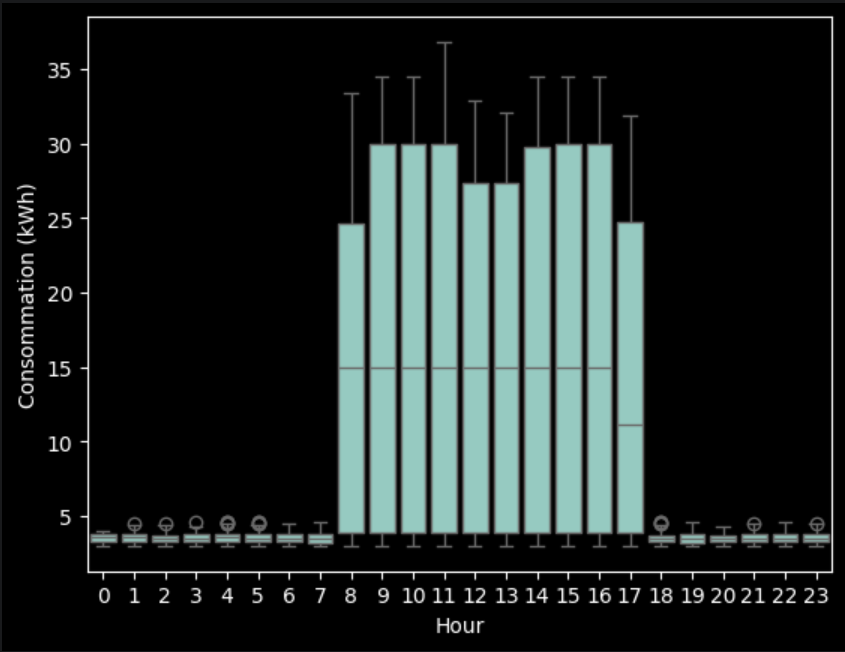

#### On observe que la consommation varie fortement selon l’heure. Elle est plus faible durant la nuit et augmente durant la journée, ce qui est cohérent avec l’activité du bâtiment. Certaines heures présentent une variabilité plus importante, ce qui peut indiquer des usages irréguliers.

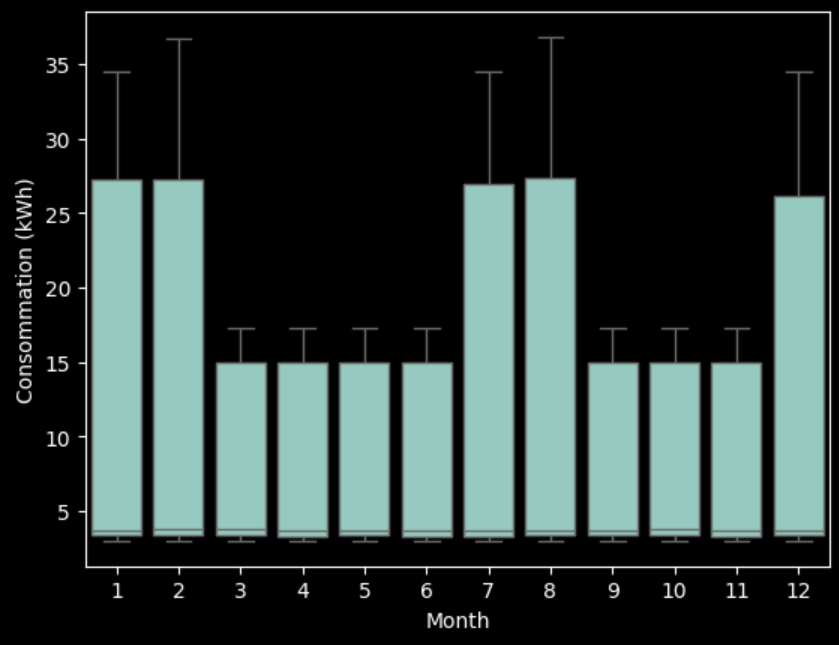

#### On observe egalement que la consomation est beaucoup plus important en Ete et en Hiver, part apport au printemps ou a l'autone. Ces observation sont totalement coherant par apport a l'utilisation de systhme de chauffage ou clime qui sont des systheme tres energivore.

## 3 model different sont tester :
1. Linear Regression
2. Random Forest
3. Gradient Boosting

In [30]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("Icare\consommation_energetique.csv", sep=";")
# print(df.columns)
df = df.drop(columns=["Date", "Label", "Year"])

print(df.head())
df.describe()
df.info()

#sns.boxplot(x="Month", y="Consommation (kWh)", data=df)
# sns.boxplot(x="State", y="Consommation (kWh)", data=df)

   Consommation (kWh)  State  Month  Day  Hour
0            3.374540  Fermé      1    1     0
1            3.751280  Fermé      1    1     1
2            3.616274  Fermé      1    1     2
3            3.035687  Fermé      1    1     3
4            3.170338  Fermé      1    1     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8761 entries, 0 to 8760
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Consommation (kWh)  8761 non-null   float64
 1   State               8761 non-null   object 
 2   Month               8761 non-null   int64  
 3   Day                 8761 non-null   int64  
 4   Hour                8761 non-null   int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 342.4+ KB


Préprocessing data set

In [31]:
import numpy as np
from sklearn.model_selection import train_test_split

df["State"] = df["State"].map({"Fermé": 0, "Ouvert": 1})  # normalisation state
df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)      # normalisation de l'heure en fonction du sin
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)      # normalisation de l'heure en fonction du sin
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)    # normalisation des mois
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

X = df.drop("Consommation (kWh)", axis=1)
y = df["Consommation (kWh)"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)  #split the data set in two part train and test




Model 1 : Linear Regression

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score
import time

start_time = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

end_time = time.time()
print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Train R2:", r2_score(y_train, lr.predict(X_train)))
print("Test R2:", r2_score(y_test,y_pred_lr))
print("Temps : ", end_time - start_time)

Linear Regression
MAE: 2.4897763571363094
Train R2: 0.8043922019084649
Test R2: 0.8013004952790969
Temps :  0.0020003318786621094


Model 2 : Random Forest


Random Forest
MAE: 0.32327954189862423
Train R2: 0.9962360651157842
Test R2: 0.9951392378197093
Temps :  0.02250838279724121


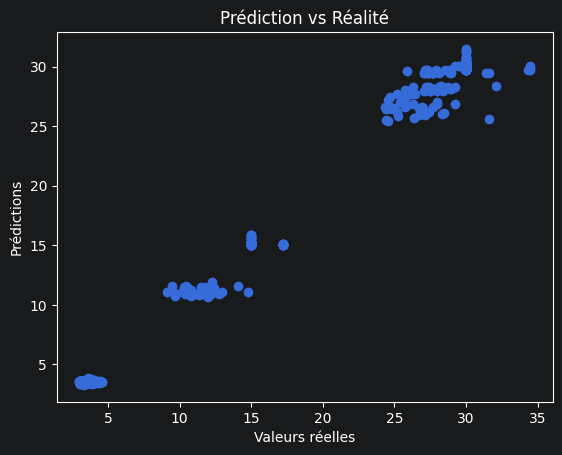

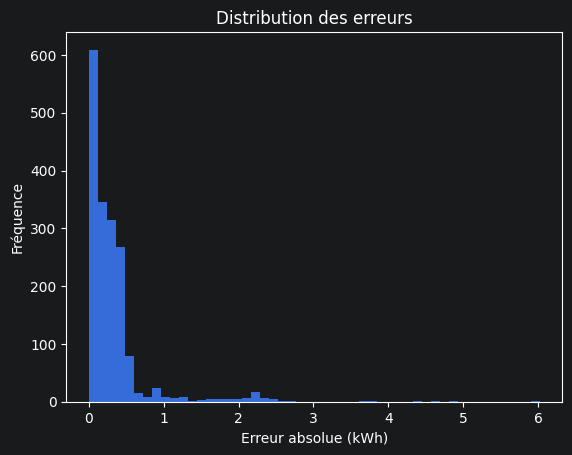

In [32]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

import time

start_time = time.time()
rf = RandomForestRegressor(n_estimators=5, max_depth= 7) #, min_samples_split=2, min_samples_leaf=1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

end_time = time.time()
print("\nRandom Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("Train R2:", r2_score(y_train, rf.predict(X_train)))
print("Test R2:", r2_score(y_test, y_pred_rf))
print("Temps : ", end_time - start_time)

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)      # R2 visualysation
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Prédiction vs Réalité")
plt.show()

errors = np.abs(y_test - y_pred_rf) # MAE visualysation
plt.hist(errors, bins=50)
plt.xlabel("Erreur absolue (kWh)")
plt.ylabel("Fréquence")
plt.title("Distribution des erreurs")
plt.show()

Model 3 : Gradient Boosting


Gradient Boosting
MAE: 0.35541019995689055
Train R2: 0.9968547505126149
Test R2: 0.9950672211123257
Temps :  0.40212249755859375


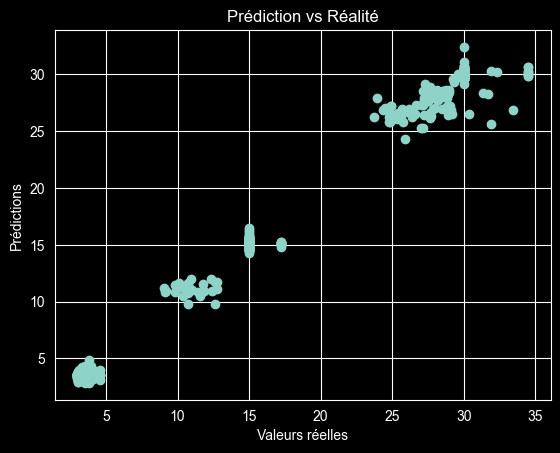

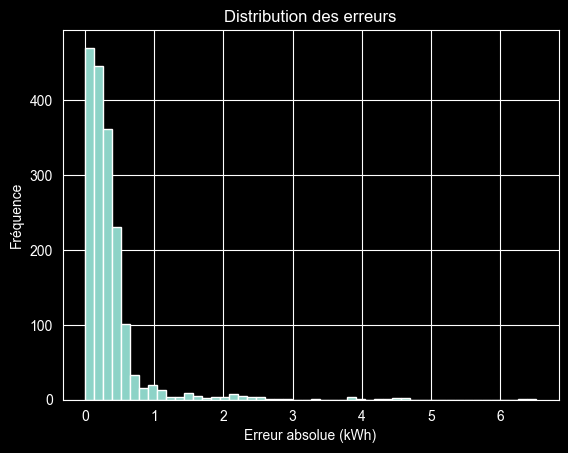

In [53]:
from sklearn.ensemble import GradientBoostingRegressor

start_time = time.time()

gb = GradientBoostingRegressor(learning_rate=0.4, n_estimators=100, max_depth = 4)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)


end_time = time.time()
print("\nGradient Boosting")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("Train R2:", r2_score(y_train, gb.predict(X_train)))
print("Test R2:", r2_score(y_test, y_pred_gb))
print("Temps : ", end_time - start_time)

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_gb)
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Prédiction vs Réalité")
plt.show()

import numpy as np          # MAE visualysation

errors = np.abs(y_test - y_pred_gb)

plt.hist(errors, bins=50)
plt.xlabel("Erreur absolue (kWh)")
plt.ylabel("Fréquence")
plt.title("Distribution des erreurs")
plt.show()

## **Test 5** avec Random Forest avec N profondeur (model 2)

In [16]:
for n in [1, 5, 10, 50, 100, 200]:
    start_time = time.time()
    rf = RandomForestRegressor(n_estimators=n)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    end_time = time.time()
    print("n_estimaors = ", n, "\tMAE = ", mean_absolute_error(y_test, pred), "\ttime : ", end_time - start_time)

n_estimaors =  1 	MAE =  0.4414185794133159 	time :  0.021998882293701172
n_estimaors =  5 	MAE =  0.35814726593108176 	time :  0.04799985885620117
n_estimaors =  10 	MAE =  0.35466370630348143 	time :  0.09299945831298828
n_estimaors =  50 	MAE =  0.3519165568200189 	time :  0.4318118095397949
n_estimaors =  100 	MAE =  0.3507230882115337 	time :  0.8541624546051025
n_estimaors =  200 	MAE =  0.3489700076988087 	time :  1.6971993446350098


## **Test 6** avec Random Forest avec D profondeur. (model 2)

In [21]:
for d in [1, 5, 7, 10, 20, None]:
    start_time = time.time()
    rf = RandomForestRegressor(max_depth=d)
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    end_time = time.time()
    print("max_depth = ", d, "\tMAE = ", mean_absolute_error(y_test, pred), "\ttime : ", end_time - start_time)

max_depth =  1 	MAE =  2.321582044154104 	time :  0.11700057983398438
max_depth =  5 	MAE =  0.404226847623218 	time :  0.28759193420410156
max_depth =  7 	MAE =  0.33112207524888 	time :  0.38166069984436035
max_depth =  10 	MAE =  0.3346347674895939 	time :  0.5070486068725586
max_depth =  20 	MAE =  0.350437119802028 	time :  0.8237488269805908
max_depth =  None 	MAE =  0.35002390139432127 	time :  0.8436684608459473


## **Test 7** avec Gradient Boosting avec un learning_rate (model 3)

In [35]:
for lr in [0.01, 0.1, 0.4, 0.5, 1, 2]:
    start_time = time.time()
    gb = GradientBoostingRegressor(learning_rate=lr)
    gb.fit(X_train, y_train)
    pred = gb.predict(X_test)
    end_time = time.time()
    print("learning_rate = ", lr, "\tMAE = ", mean_absolute_error(y_test, pred), "\ttime : ", end_time - start_time)

learning_rate =  0.01 	MAE =  2.701701014798631 	time :  0.2594325542449951
learning_rate =  0.1 	MAE =  0.3971299120823285 	time :  0.2735731601715088
learning_rate =  0.4 	MAE =  0.36611009184265214 	time :  0.25999999046325684
learning_rate =  0.5 	MAE =  0.375263986527246 	time :  0.26400017738342285
learning_rate =  1 	MAE =  0.37987496793165587 	time :  0.2617497444152832
learning_rate =  2 	MAE =  7.222758610242818 	time :  0.24972057342529297


## **Test 8** avec Gradient Boosting avec n n_estimators (model 3)

In [38]:
for n in [50, 100, 200, 400, 500, 600, 800, 1000]:
    start_time = time.time()
    gb = GradientBoostingRegressor(n_estimators=n)
    gb.fit(X_train, y_train)
    pred = gb.predict(X_test)
    end_time = time.time()
    print("n_estimator = ", n, "\tMAE = ",mean_absolute_error(y_test, pred), "\ttime : ", end_time - start_time)

n_estimator =  50 	MAE =  0.5344908571178646 	time :  0.13309884071350098
n_estimator =  100 	MAE =  0.3971299120823286 	time :  0.25109338760375977
n_estimator =  200 	MAE =  0.37699792345740246 	time :  0.5149705410003662
n_estimator =  400 	MAE =  0.3691985643934303 	time :  1.0606887340545654
n_estimator =  500 	MAE =  0.36174478724252473 	time :  1.2998952865600586
n_estimator =  600 	MAE =  0.362356164296375 	time :  1.5796573162078857
n_estimator =  800 	MAE =  0.36303152118470605 	time :  2.0711445808410645
n_estimator =  1000 	MAE =  0.36223588668993684 	time :  2.5968852043151855


## **Test 9** avec Gradient Boosting avec x max_depth (model 3)

In [43]:
for d in [1, 2, 3, 4, 5, 10, 20, None]:
    start_time = time.time()
    gb = GradientBoostingRegressor(max_depth= d)
    gb.fit(X_train, y_train)
    pred = gb.predict(X_test)
    end_time = time.time()
    print("max_depth = ", d, "\tMAE = ",mean_absolute_error(y_test, pred), "\ttime : ", end_time - start_time)

max_depth =  1 	MAE =  2.505831575820516 	time :  0.12353634834289551
max_depth =  2 	MAE =  1.68233973257267 	time :  0.1814098358154297
max_depth =  3 	MAE =  0.3971299120823284 	time :  0.2638120651245117
max_depth =  4 	MAE =  0.3530265800600005 	time :  0.3272063732147217
max_depth =  5 	MAE =  0.3386278884065115 	time :  0.4152944087982178
max_depth =  10 	MAE =  0.3937337907981142 	time :  0.7433936595916748
max_depth =  20 	MAE =  0.43414798856317166 	time :  1.315551519393921
max_depth =  None 	MAE =  0.441604323392912 	time :  1.3161883354187012


# Remarque :

### il est tres important de faire du processing avec la donné du data set.
* Pour rappel le sin() et cos() on une valeur comprise entre [1 et -1];
1. l'heure allant de O à 23 il est possible que le model les considere tres different alors que se sont des valeur tres proche au nivau de l'heure.
2. de meme pour les mois allant de 1 a 12, le model vois des valeur tres eloigner, mais en realiter janvier est juste apres descembre.

### Interpretation des resultat:
1. R² (coefficient de détermination)
* a quel point ton modèle est meilleur qu’un modèle qui predit toujour la moyenne de consomation
* plus R² est proche de 1 → mieux

2. MAE (Mean Absolute Error)
* erreur moyenne entre ta prédiction et la vraie valeur.
* MAE = 0.37 → ton modèle se trompe en moyenne de 0.37 kWh
* plus MAE est faible → mieux

# Resultat des tests :

### Test 1 : Model 1, Linear Regression

Linear Regression <br>
MAE: 2.5194604709726818 <br>
R2: 0.7985364850292678 <br>
Temps :  0.0029993057250976562 <br>

**conclusion :**
* MAE est tres elever et R2 asser eloigner de 1.
* resultat obtenue en 31ms
* **model non adapter** : modèle linéaire le problème est clairement non linéaire (cycles, saisons, ouverture...)

### Test 2 : Model 2, Random Forest RandomForestRegressor(n_estimators=100)

Random Forest <br>
MAE: 0.3702876858291681 <br>
R2: 0.9936718185224018 <br>
Temps :  0.8399991989135742 <br>

**conclusion :**
* MAE est tres proche de O, et R2 est egalement tres proche de 1.
* resultat en 167ms.
* Model tres encouragent

### Test 3 : Model 3 Gradient Boosting

Gradient Boosting <br>
MAE: 0.4059852176696125 <br>
R2: 0.9940016379352701 <br>
Temps :  0.26199936866760254 <br>

**conclusion :**
* MAE un peu plus elever que le model 2, mais un R2 qui est plus elever dans ce test ci.
* Neamoins ce model prend 3 fois moins de temps ce qui est tres interessant.

### Ajoue d'une verification pour l'overfitting compare le score R2 de l'entrainement et du test.

### Test 4 :  model 1 + 2 + 3 avec la verification de l'overfitting

Linear Regression <br>
MAE: 2.5194604709726818 <br>
Train R2: 0.8050917647139294 <br>
Test R2: 0.7985364850292678 <br>
Temps :  0.0019998550415039062 <br>

Random Forest <br>
MAE: 0.3691643839099341 <br>
Train R2: 0.9992863051526412 <br>
Test R2: 0.9938389632256933 <br>
Temps :  0.8579988479614258 <br>

Gradient Boosting <br>
MAE: 0.40598521766961243 <br>
Train R2: 0.9945875543347438 <br>
Test R2: 0.9940016379352701 <br>
Temps :  0.2619955539703369 <br>

**conclusion :**
* les 3 model on sensiblement les meme R2 pour le Train et le Test. ce qui prouve qui ne sont pas overfitting.
* De plus les graphique montre des nuage proche de la diagonale ce qui montre de bon modèle.

# conclusion Intermediaire:

* La régression linéaire (model 1) est moins performante car elle ne capture pas les relations complexes entre les variables.
* Les modèles non linéaires (Random Forest et Gradient Boosting) donnent de très bonnes performances avec un R² proche de 1 et une faible erreur.
* Le Gradient Boosting est particulièrement intéressant car il offre des performances similaires au Random Forest tout en étant plus rapide.

### Test 5 : Model 2, Random Forest avec RandomForestRegressor(n_estimators)

n_estimaors =  1 	MAE =  0.4414185794133159 	time :  0.021998882293701172 <br>
n_estimaors =  5 	MAE =  0.35814726593108176 	time :  0.04799985885620117 <br>
n_estimaors =  10 	MAE =  0.35466370630348143 	time :  0.09299945831298828 <br>
n_estimaors =  50 	MAE =  0.3519165568200189 	time :  0.4318118095397949 <br>
n_estimaors =  100 	MAE =  0.3507230882115337 	time :  0.8541624546051025 <br>
n_estimaors =  200 	MAE =  0.3489700076988087 	time :  1.6971993446350098 <br>

**conclusion :**
* plus n_estimaors est bas plus le model est rapide. MAE est reste presque le meme jusqua **n_estimator = 5**.

### Test 6 : Model 2, Random Forest avec RandomForestRegressor(max_depth)

max_depth =  1 	MAE =  2.321582044154104 	time :  0.11700057983398438 <br>
max_depth =  5 	MAE =  0.404226847623218 	time :  0.28759193420410156 <br>
max_depth =  7 	MAE =  0.33112207524888 	time :  0.38166069984436035 <br>
max_depth =  10 	MAE =  0.3346347674895939 	time :  0.5070486068725586 <br>
max_depth =  20 	MAE =  0.350437119802028 	time :  0.8237488269805908 <br>
max_depth =  None 	MAE =  0.35002390139432127 	time :  0.8436684608459473 <br>

**conclusion :**
* plus le max_depth est elever plus le model prend du temp, cependant apres 5 le model a sont MAE qui s'envole.  **max_depth = 7**

### Test 7 : Model 3, Gradient Boosting avec GradientBoostingRegressor(learning_rate)

learning_rate =  0.01 	MAE =  2.701701014798631 	time :  0.2594325542449951 <br>
learning_rate =  0.1 	MAE =  0.3971299120823285 	time :  0.2735731601715088 <br>
learning_rate =  0.4 	MAE =  0.36611009184265214 	time :  0.25999999046325684 <br>
learning_rate =  0.5 	MAE =  0.375263986527246 	time :  0.26400017738342285 <br>
learning_rate =  1 	MAE =  0.37987496793165587 	time :  0.2617497444152832 <br>
learning_rate =  2 	MAE =  7.222758610242818 	time :  0.24972057342529297 <br>

**conclusion :**
* peut importe le learning_rate le temp reste globalement le meme.
* neamoins le MAE est le plus proche de 0 avec **learning_rate = 0.4**

### Test 8 : Model 3, Gradient Boosting avec GradientBoostingRegressor(n_estimators)

n_estimator =  50 	MAE =  0.5344908571178646 	time :  0.13309884071350098 <br>
n_estimator =  100 	MAE =  0.3971299120823286 	time :  0.25109338760375977 <br>
n_estimator =  200 	MAE =  0.37699792345740246 	time :  0.5149705410003662 <br>
n_estimator =  400 	MAE =  0.3691985643934303 	time :  1.0606887340545654 <br>
n_estimator =  500 	MAE =  0.36174478724252473 	time :  1.2998952865600586 <br>
n_estimator =  600 	MAE =  0.362356164296375 	time :  1.5796573162078857 <br>
n_estimator =  800 	MAE =  0.36303152118470605 	time :  2.0711445808410645 <br>
n_estimator =  1000 	MAE =  0.36223588668993684 	time :  2.5968852043151855 <br>

**conclusion :**
* n_estimator a un tres grose inpact sur le temps, mais tres peut sur MAE.
* **n_estimator = 100**

### **Test 9** Model 3, Gradient Boosting avec GradientBoostingRegressor(max_depth)

max_depth =  1 	MAE =  2.505831575820516 	time :  0.12353634834289551 <br>
max_depth =  2 	MAE =  1.68233973257267 	time :  0.1814098358154297 <br>
max_depth =  3 	MAE =  0.3971299120823284 	time :  0.2638120651245117 <br>
max_depth =  4 	MAE =  0.3530265800600005 	time :  0.3272063732147217 <br>
max_depth =  5 	MAE =  0.3386278884065115 	time :  0.4152944087982178 <br>
max_depth =  10 	MAE =  0.3937337907981142 	time :  0.7433936595916748 <br>
max_depth =  20 	MAE =  0.43414798856317166 	time :  1.315551519393921 <br>
max_depth =  None 	MAE =  0.441604323392912 	time :  1.3161883354187012 <br>

**conclusion :**
* plus max depth est profond plus il prend du temp, malheuresement MAE  ne descend pas en dessous de 0.35
* max_depth = 4

### **Test 10** Model 2 + 3 avec les hyper parametre determiner lors du test 5 à 9 .

Random Forest <br>
MAE: 0.33607198645118835 <br>
Train R2: 0.9963088242958525 <br>
Test R2: 0.9950974659608134 <br>
Temps :  0.03193521499633789 <br>
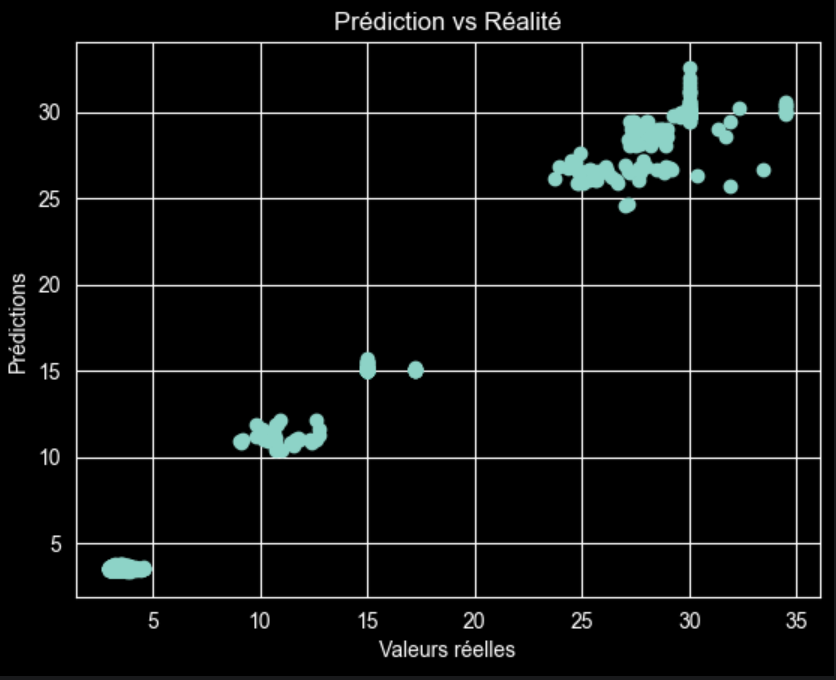
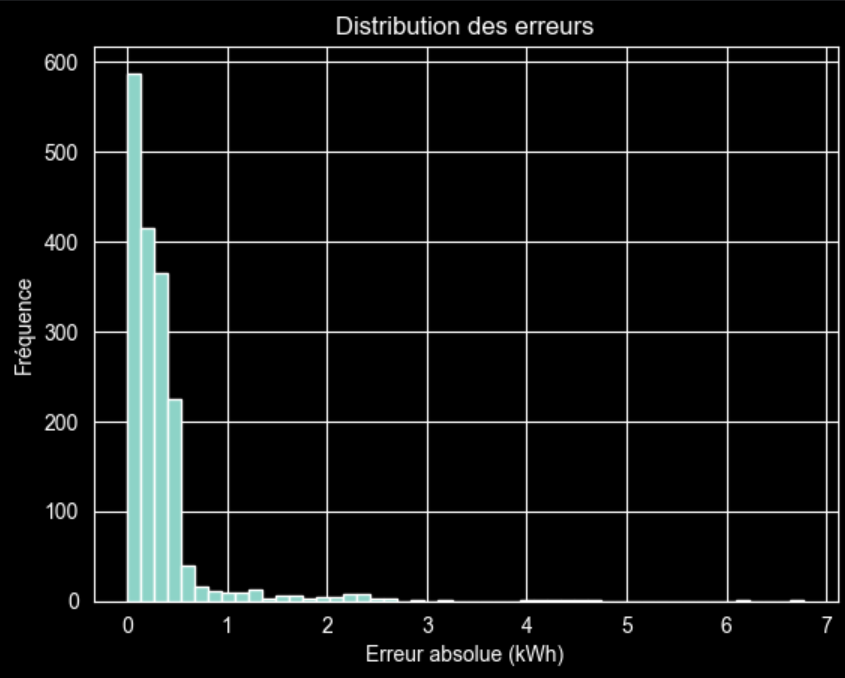

Gradient Boosting <br>
MAE: 0.3554101999568904 <br>
Train R2: 0.9968547505126149 <br>
Test R2: 0.9950672211123257 <br>
Temps :  0.3406665325164795 <br>
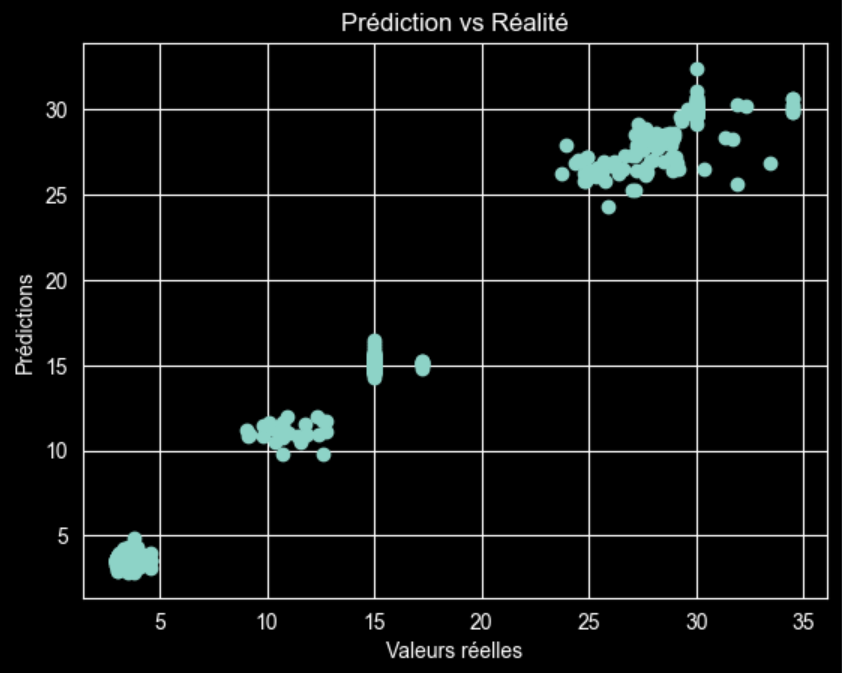
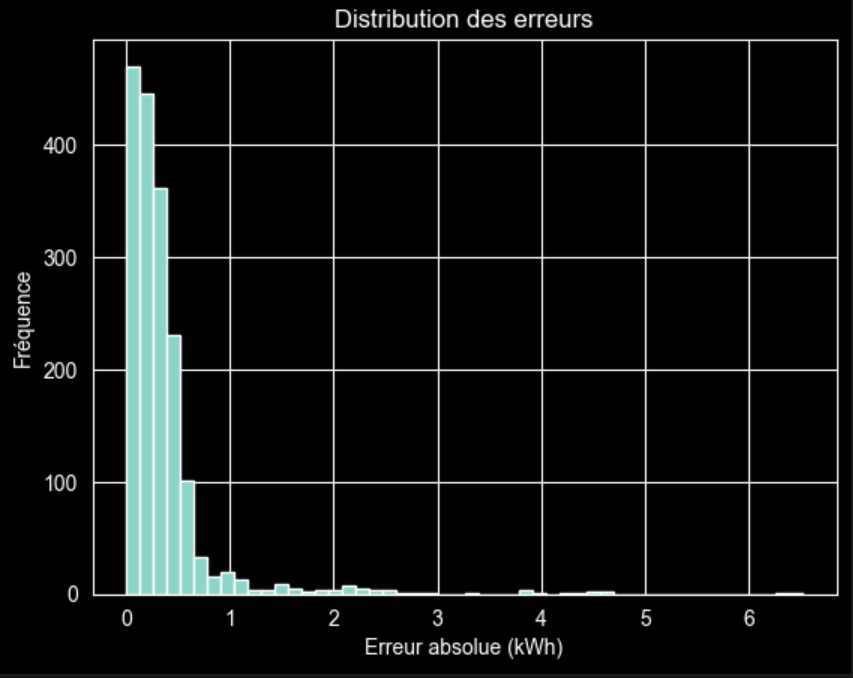

# conclusion :

* Les modèles non linéaires (Random Forest et Gradient Boosting) donnent de très bonnes performances avec un R² proche de 1 et une faible erreur.
* contrairement a la conclution intermediare une fois les hyperParametre fixer on sen rend compte que :
1. Random Forest est plus de 10 fois plus rapide que Gradient Boosting
2. que cest deux model on des R2 test ou entrainement tres proche l'un de l'autre
3. le MAE de Random Forest est un peut plus petit que l'autre model